In [47]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\Asus\Desktop\telco-churn-analytics\data\TelcoCustomerChurn.csv')

print(df.shape)          # rows, columns
df.head()                # first 5 rows

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()                # column names, data types, non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.describe()            # summary of numeric columns
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# Step 2 of 8: Clean the Data

## Find the Problems

In [4]:
# 1. Missing values per column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [42]:
# 2. Duplicate rows and duplicate customer IDs
print(df.duplicated().sum())
print(df["customerID"].duplicated().sum())

0
0


In [ ]:
# 3. TotalCharges is usually text. Check it:
df["TotalCharges"].dtype
df[df["TotalCharges"].str.strip() == ""].shape   
# 11, 21
# 11 are empty rows are empty string and 21 are columns

(11, 21)

In [7]:
# Convert TotalCharges to numbers; blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# How many missing now?
print(df["TotalCharges"].isnull().sum())

11


### Code: Fix Them

In [8]:
# Convert TotalCharges to numbers; blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# How many missing now?
print(df["TotalCharges"].isnull().sum())

11


In [48]:
# Those rows have tenure = 0 (brand-new customers), so their total is really 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [10]:
# Make Churn numeric for later analysis (1 = left, 0 = stayed)
df["Churn_flag"] = df["Churn"].map({"Yes": 1, "No": 0})

# SeniorCitizen is 0/1, so show it as a category label
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [49]:
# Final check
df.info()
df.isnull().sum().sum()   # should be 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

# EDA and Visualization

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# This makes seaborn's charts use a clean, readable style by default
sns.set_style("whitegrid")

### 3 Churn Distribution (the target variable)

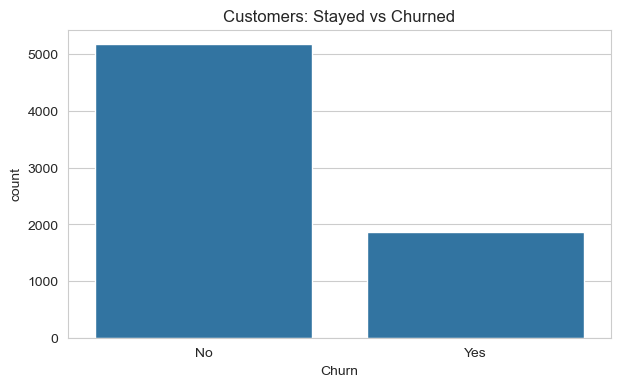

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [17]:
# countplot() counts how many rows fall into each category of a column
# and draws a bar for each — here, how many customers churned vs stayed
sns.countplot(x="Churn", data=df)
plt.title("Customers: Stayed vs Churned")
plt.show()

# normalize=True turns the counts into percentages (proportions) instead of raw numbers,
# which is easier to read: e.g. "26.5% churned" instead of "1869 churned"
print(df["Churn"].value_counts(normalize=True) * 100)

### 4. Code: Numeric Features — Distribution

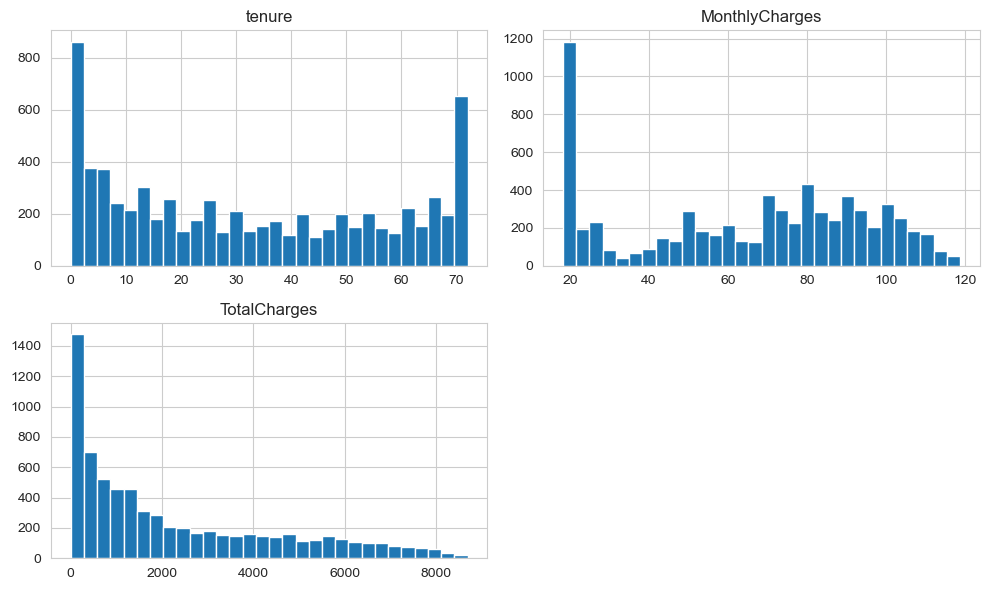

In [18]:
# hist() draws a histogram: it groups values into bins (ranges)
# and shows how many rows fall into each bin.
# figsize controls the overall chart size (width, height in inches)
df[["tenure", "MonthlyCharges", "TotalCharges"]].hist(figsize=(10, 6), bins=30)
plt.tight_layout()   # prevents chart titles/labels from overlapping
plt.show()

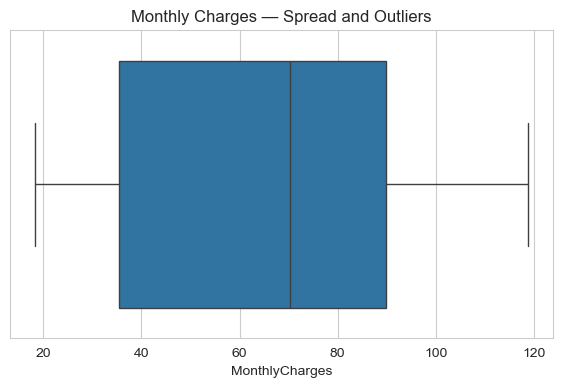

In [19]:
# boxplot() shows the spread of a numeric column and highlights outliers
# (points far above or below the "box") — useful before we formally
# handle outliers in Session 10
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Monthly Charges — Spread and Outliers")
plt.show()

### 5. Code: Categorical Features vs Churn (the real business insight)

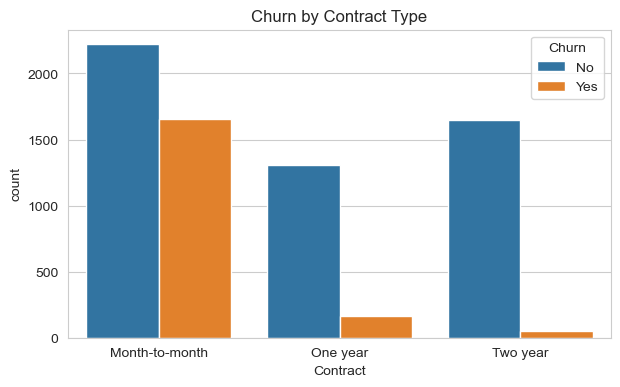

In [20]:
# This compares Churn split by Contract type.
# hue="Churn" splits each Contract bar into "stayed" vs "churned" sub-bars,
# so we can see which contract type has the worst churn rate
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

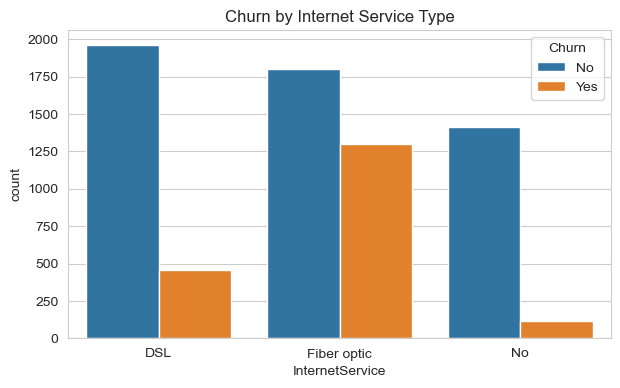

In [21]:
# Same idea, but for Internet Service type
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service Type")
plt.show()

In [22]:
# groupby() splits the data into groups (here, by Contract),
# then we calculate the mean of Churn_flag for each group.
# Since Churn_flag is 1 (left) or 0 (stayed), the mean IS the churn rate.
# Example: mean of [1,0,0,1] = 0.5 → 50% churn rate in that group
df.groupby("Contract")["Churn_flag"].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_flag, dtype: float64

### 6. Code: Correlation Preview (numeric columns only)

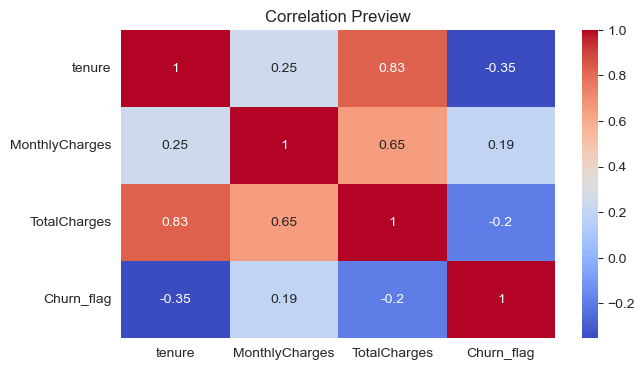

In [23]:
# corr() calculates how strongly each numeric column moves together with others
# (a first look — Session 10 covers this properly with Pearson correlation)
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_flag"]

# annot=True prints the actual correlation numbers on the heatmap
# cmap sets the color scheme; coolwarm makes negative/positive easy to spot
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Preview")
plt.show()

# Step 4 of 8: Descriptive Statistics

In [24]:
# describe() automatically calculates count, mean, std, min, 25%, 50%,
# 75%, and max for every numeric column in one line
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [25]:
# Mode is not included in describe(), because it applies more naturally
# to categorical data. mode() returns the most frequently occurring value(s).
df["tenure"].mode()[0]
df["Contract"].mode()[0]

'Month-to-month'

In [26]:
# Quartiles and IQR (Interquartile Range) show the middle 50% of data,
# which is more robust to outliers than looking at min/max.
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

Q1: 35.5, Q3: 89.85, IQR: 54.349999999999994


In [27]:
# Coefficient of Variation (CV) = (Std Dev / Mean) * 100
# It expresses spread as a PERCENTAGE of the mean, so you can compare
# variability across columns that have very different scales
# (e.g. comparing spread of tenure in months vs charges in dollars).
cv_tenure = (df["tenure"].std() / df["tenure"].mean()) * 100
cv_charges = (df["MonthlyCharges"].std() / df["MonthlyCharges"].mean()) * 100
print(f"CV Tenure: {cv_tenure:.2f}%, CV MonthlyCharges: {cv_charges:.2f}%")

CV Tenure: 75.87%, CV MonthlyCharges: 46.46%


In [28]:
# Compare descriptive stats for churned vs non-churned customers separately —
# this connects statistics directly back to our business question.
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


## Part 2: Our Approach

### A. Manual Conditional Probability

In [29]:
# Conditional probability: P(Churn=Yes | Contract=Month-to-month)
# This is just the churn rate within that one group — same idea as our
# earlier groupby, but now framed explicitly as a conditional probability.
p_churn_given_mtm = df[df["Contract"] == "Month-to-month"]["Churn_flag"].mean()
print(f"P(Churn | Month-to-month) = {p_churn_given_mtm:.3f}")

P(Churn | Month-to-month) = 0.427


### B. Preparing Data for the Model

In [30]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Pick a few categorical features that showed strong patterns in EDA
features = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]
X = df[features].copy()
y = df["Churn_flag"]

# Naive Bayes needs numbers, not text, so we encode each category as an integer.
# LabelEncoder assigns each unique text value a number (e.g. "DSL"->0, "Fiber optic"->1)
encoders = {}
for col in features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le   # save it, so we can decode predictions later if needed

# Split data: 80% to train the model, 20% to test it on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y keeps the same churn ratio in both train and test sets,
# important because our data is imbalanced (73%/27%)

### C. Training and Testing the Model

In [31]:
# Train the Naive Bayes model on the training data
model = CategoricalNB()
model.fit(X_train, y_train)

# Predict on unseen test data
y_pred = model.predict(X_test)

# Quick accuracy check (we'll cover better metrics in Step 7)
from sklearn.metrics import accuracy_score
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.772


# Step 6 — Predictive Modelling with Decision Tree

In [32]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Use more features now, including the numeric ones — trees handle mixed types well
features = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen",
            "tenure", "MonthlyCharges"]
X = df[features].copy()
y = df["Churn_flag"]

# Encode remaining text columns
for col in ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]:
    X[col] = LabelEncoder().fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
# max_depth limits how many splits deep the tree can go.
# Without a limit, trees tend to memorize the training data (overfitting) —
# we cover this formally in Step 7, but we cap it here as good practice.
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_tree):.3f}")

Decision Tree Accuracy: 0.793


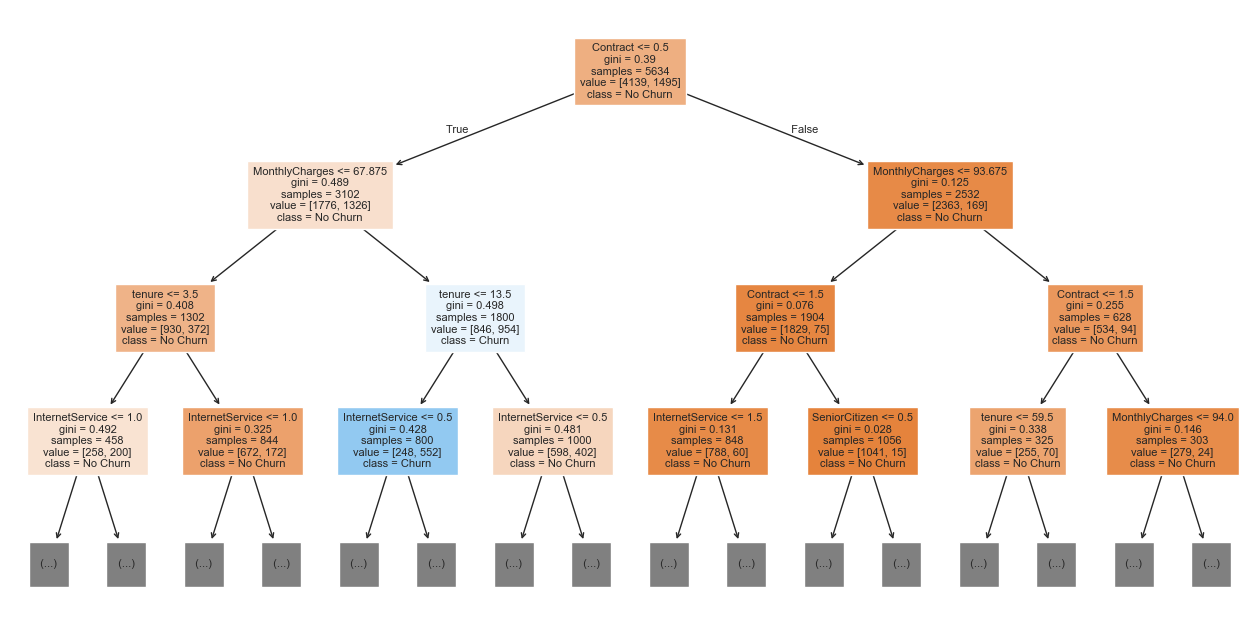

In [34]:
# plot_tree() visualizes the actual splits the model learned —
# great for explaining "why" the model predicts what it does.
plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=features, class_names=["No Churn", "Churn"],
          filled=True, max_depth=3, fontsize=8)
plt.show()

In [35]:
# feature_importances_ tells us which features the tree relied on most —
# this is the tree's version of "informative attributes"
importances = pd.Series(tree_model.feature_importances_, index=features)
importances.sort_values(ascending=False)

Contract           0.588206
tenure             0.169827
MonthlyCharges     0.164220
InternetService    0.077529
SeniorCitizen      0.000218
PaymentMethod      0.000000
dtype: float64

# Step 7 — Model Evaluation

[[941  94]
 [198 176]]


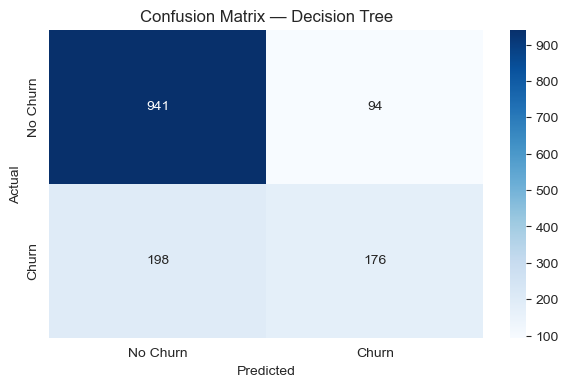

In [36]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score

# Confusion matrix: shows actual vs predicted counts in a 2x2 grid
# rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred_tree)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Decision Tree")
plt.show()

In [38]:
# classification_report gives precision, recall, and F1-score per class in one go
print(classification_report(y_test, y_pred_tree, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [39]:
# predict_proba gives the probability of churn (not just yes/no),
# which roc_auc_score needs to measure how well the model ranks
# churners above non-churners across all thresholds.
y_proba = tree_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.826


In [40]:
# cross_val_score trains and tests the model 5 separate times on different
# slices of the data, so we get a more reliable performance estimate
# than a single train/test split — and it shows if performance is unstable.
cv_scores = cross_val_score(tree_model, X, y, cv=5, scoring="accuracy")
print(f"Cross-val scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.3f}, Std: {cv_scores.std():.3f}")

Cross-val scores: [0.78921221 0.77785664 0.77430802 0.79403409 0.79971591]
Mean: 0.787, Std: 0.010
